# 🏥LIVER DISEASE PREDICTION
## TEAM ID : PTID-CDS-OCT-25-3292
## PROJECT ID : PRCP-1007-LiverPatientPred


# PROBLEM STATEMENT

**Patients with Liver disease have been continuously increasing because of excessive consumption of alcohol, inhale of harmful gases, intake of contaminated food, pickles and drugs. This dataset was used to evaluate prediction algorithms in an effort to reduce burden on doctors.**


---


**Liver diseases are a major global health concern and can lead to severe complications if not detected early. Each patient’s health risk varies depending on several biological indicators such as bilirubin levels, enzyme activities, and protein ratios.
The goal of this project is to predict whether a patient is likely to have a liver disease based on their medical test results and demographic details.**

# Import Library's

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

# Data Collection

In [2]:
columns =["Age",
           "Gender",
           "Total Bilirubin",
           "Direct Bilirubin",
           "Alkaline Phosphotase",
           "Alamine Aminotransferase",
           "Aspartate Aminotransferase",
           "Total Protiens",
           "Albumin",
           "Albumin and Globulin Ratio",
           "Target"]
Data = pd.read_csv("/content/Indian Liver Patient Dataset (ILPD).csv",header=None,names=columns)

# IMPORT DATASET



*   "Age" --> patient age
*  "Gender"--> male or female
*  "Total Bilirubin",
           "Direct Bilirubin" --> Bilirubin
 *  "Alkaline Phosphotase","Alamine Aminotransferase","Aspartate Aminotransferase"--> Enzymes
  * "Total Protiens"--> proteins
  * "Albumin"-->to check how well the liver is working because the liver produces this protein
  * "Albumin and Globulin Ratio"
  * Target --> field used to split the data into two sets (1 : patient with  liver disease and 2: patient with no liver disease disease)



In [3]:
df = Data.copy()

In [4]:
df

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [5]:
df.shape

(583, 11)

In [6]:
df.describe(include="O")

,Gender
count,583
unique,2
top,Male
freq,441


In [7]:
df.head()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [8]:
df.tail()

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


# Summary of statistics

In [9]:
df.describe()

,Age,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [10]:
df.describe(include='all')

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
count,583.000000,583,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,44.746141,NaN,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,NaN,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,NaN,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,NaN,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,NaN,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,NaN,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000


# Find the null values

In [11]:
df.isnull().sum()

,0
Age,0
Gender,0
Total Bilirubin,0
Direct Bilirubin,0
Alkaline Phosphotase,0
Alamine Aminotransferase,0
Aspartate Aminotransferase,0
Total Protiens,0
Albumin,0
Albumin and Globulin Ratio,4


## Null values replace with median

In [12]:
df['Albumin and Globulin Ratio'].fillna(df['Albumin and Globulin Ratio'].median(), inplace=True)

# Find the duplicated

In [13]:
df.loc[df.duplicated()]

,Age,Gender,Total Bilirubin,Direct Bilirubin,Alkaline Phosphotase,Alamine Aminotransferase,Aspartate Aminotransferase,Total Protiens,Albumin,Albumin and Globulin Ratio,Target
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.80,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,1
34,38,Female,2.6,1.2,410,59,57,5.6,3.0,0.80,2
55,42,Male,8.9,4.5,272,31,61,5.8,2.0,0.50,1
62,58,Male,1.0,0.5,158,37,43,7.2,3.6,1.00,1
106,36,Male,5.3,2.3,145,32,92,5.1,2.6,1.00,2
108,36,Male,0.8,0.2,158,29,39,6.0,2.2,0.50,2
138,18,Male,0.8,0.2,282,72,140,5.5,2.5,0.80,1
143,30,Male,1.6,0.4,332,84,139,5.6,2.7,0.90,1
158,72,Male,0.7,0.1,196,20,35,5.8,2.0,0.50,1


## Remove the Duplicates values

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

# Treat the Categorical Feature

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

Change the Target values from 1 and 2 (1 : patient with  liver disease and 2: patient with no liver disease disease) to 0 and 1 (1 : patient with  liver disease and 0: patient with no liver disease disease)

In [17]:
df['Target'] = df['Target'].map({1: 1, 2: 0})

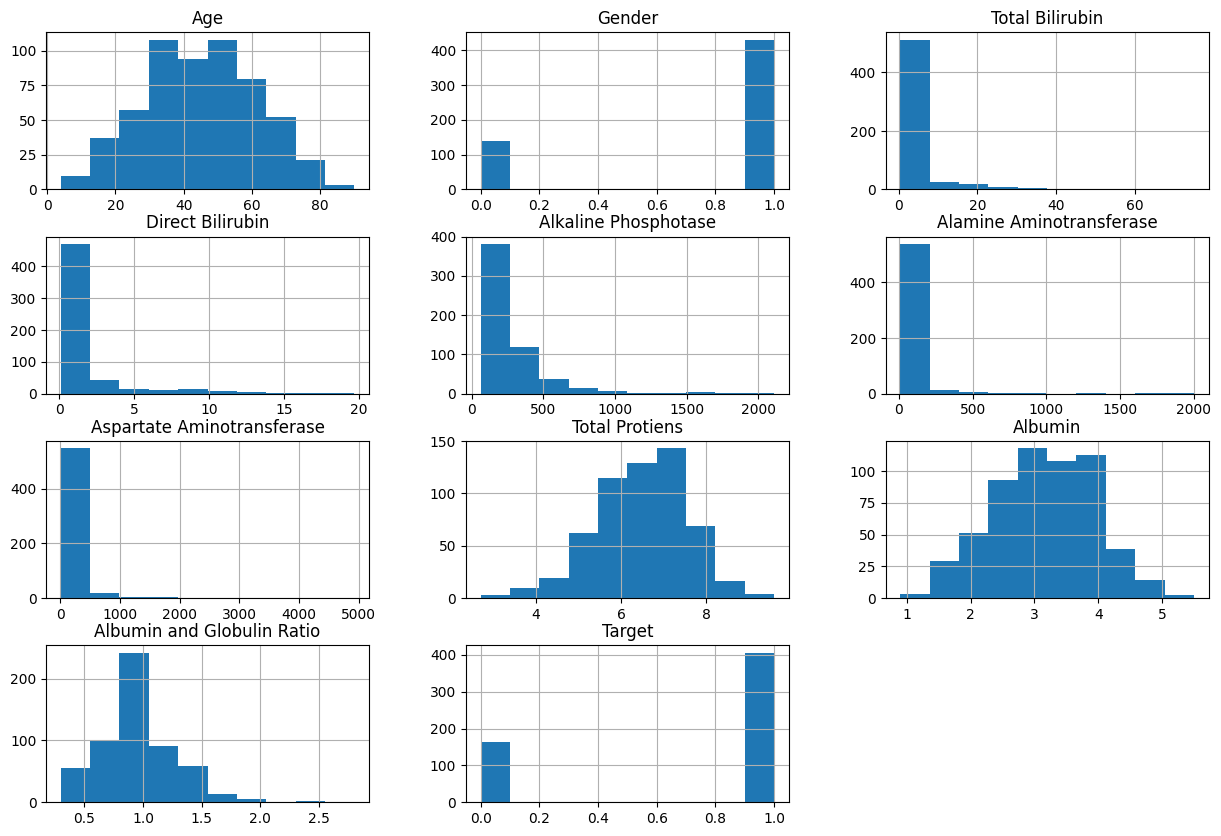

In [18]:

df.hist(figsize=(15,10))
plt.show()

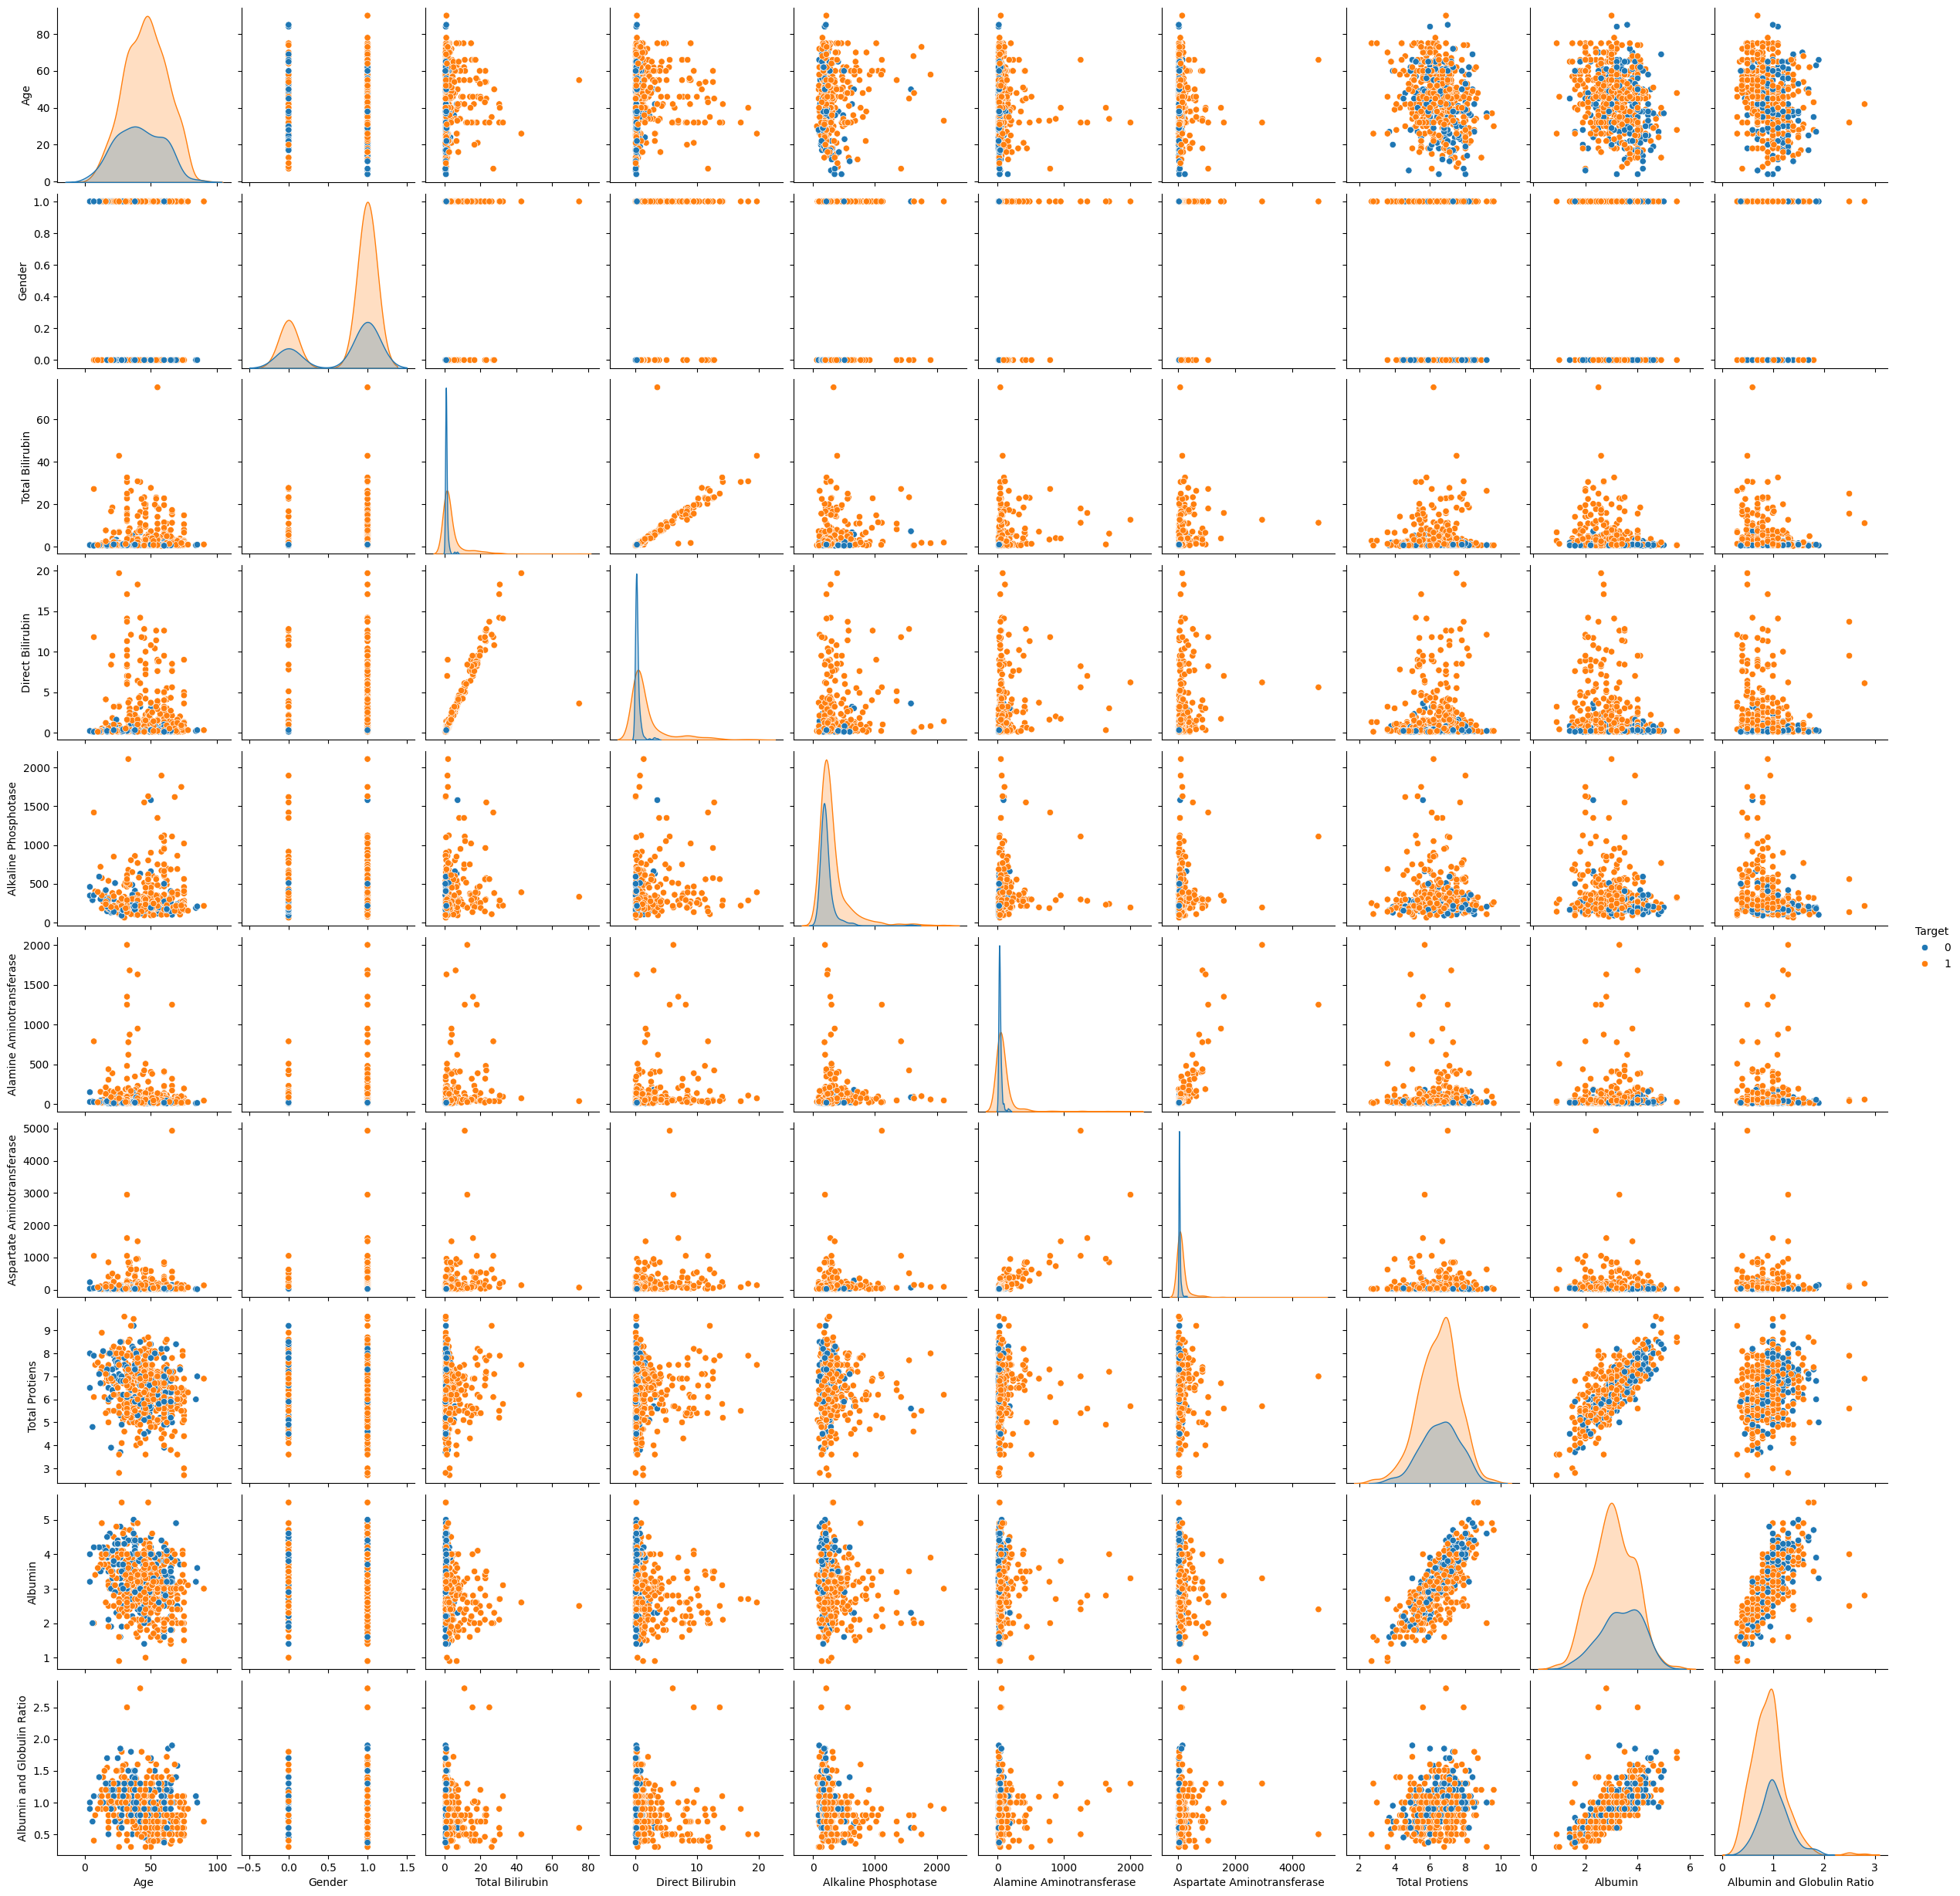

In [19]:
sns.pairplot(df,hue='Target')
plt.show()

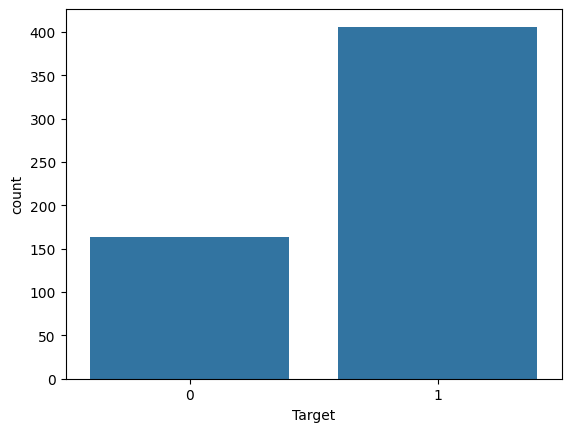

In [20]:
sns.countplot(x='Target',data=df)
plt.show()

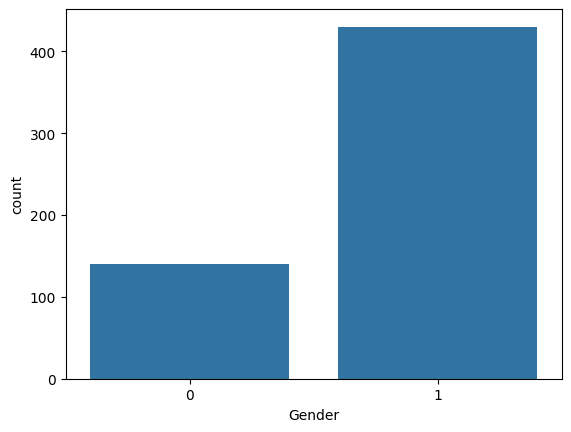

In [21]:
sns.countplot(x='Gender',data=df)
plt.show()

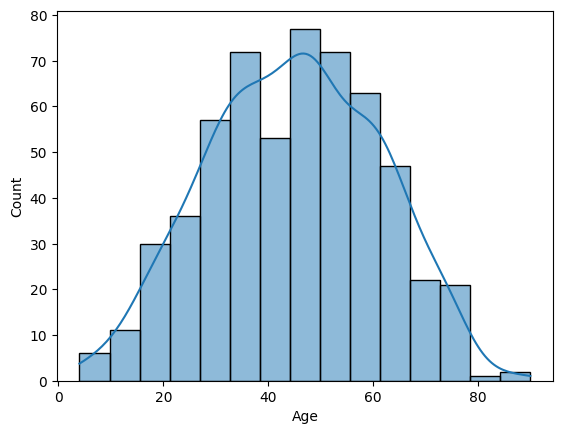

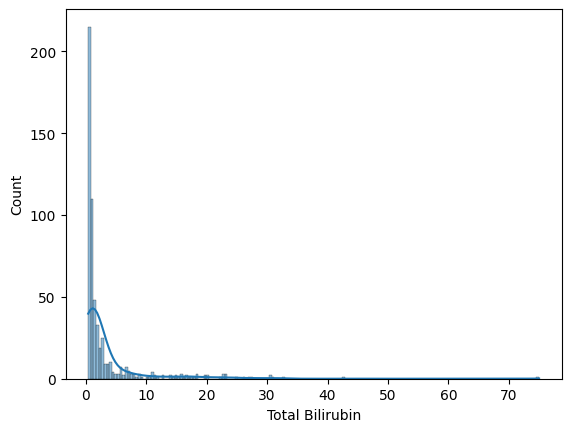

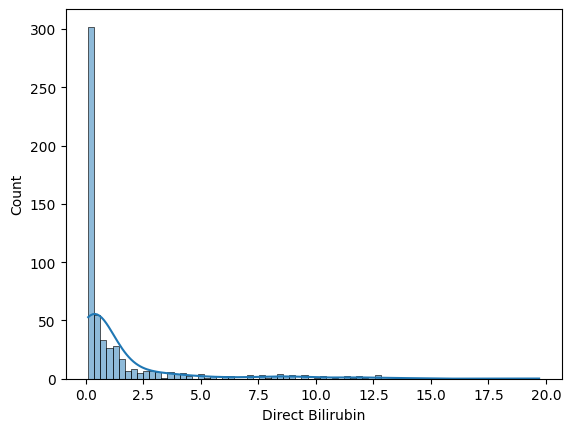

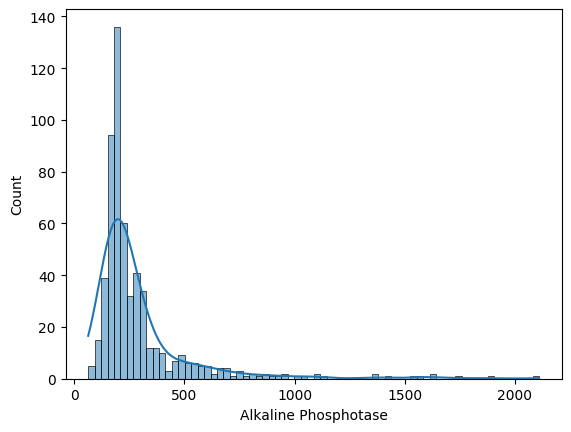

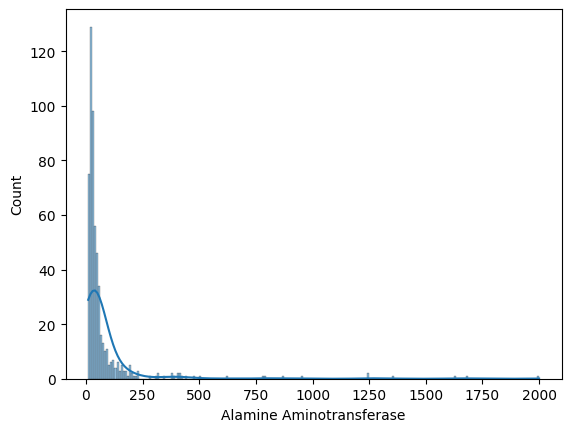

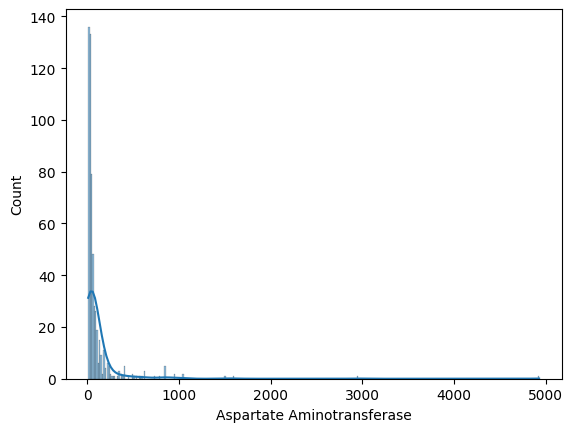

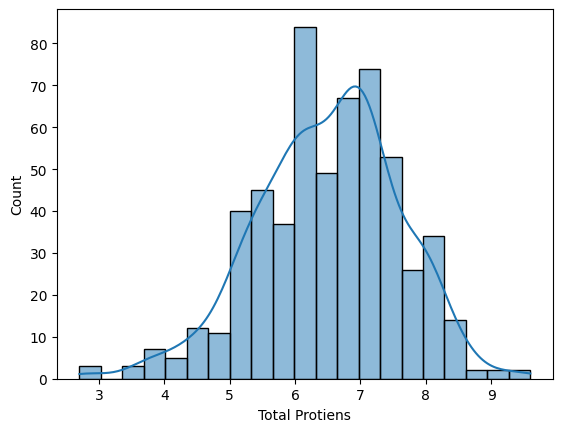

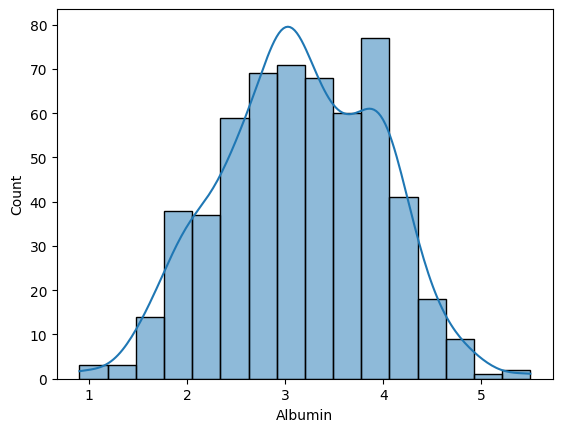

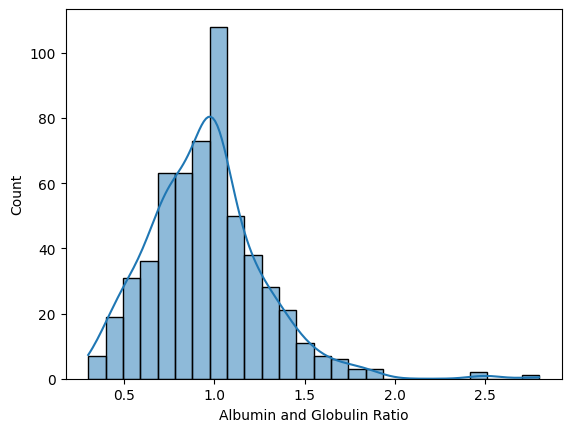

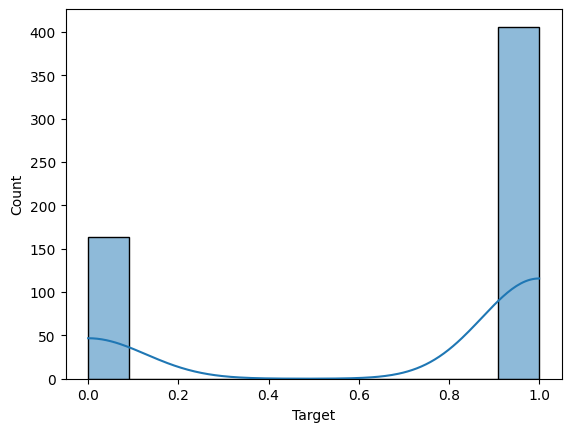

In [22]:
num_hist = ['Age', 'Total Bilirubin', 'Direct Bilirubin',
       'Alkaline Phosphotase', 'Alamine Aminotransferase',
       'Aspartate Aminotransferase', 'Total Protiens', 'Albumin',
       'Albumin and Globulin Ratio', 'Target']
for i in num_hist:
  sns.histplot(df[i],kde=True)
  plt.show()

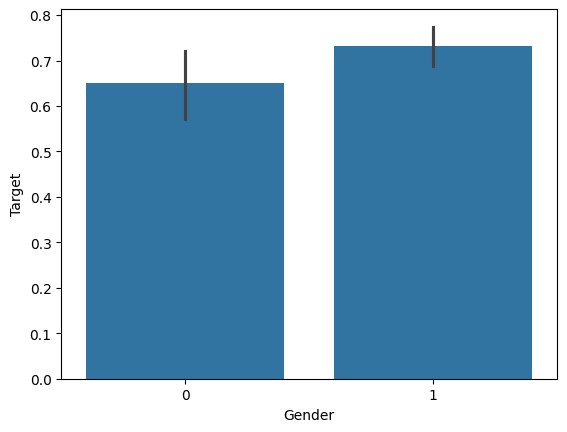

In [23]:
sns.barplot(x='Gender',y='Target',data=df)
plt.show()

# Feature Selection

In [24]:
# df['Direct Bilirubin Ratio'] = df['Direct Bilirubin']/df['Total Bilirubin']
# df['AST_ALT_Ratio'] = df['Aspartate Aminotransferase'] / df['Alamine Aminotransferase']

In [25]:
# sns.boxplot(df['Direct Bilirubin Ratio'])
# plt.show()

In [26]:
# sns.boxplot(df['AST_ALT_Ratio'])
# plt.show()

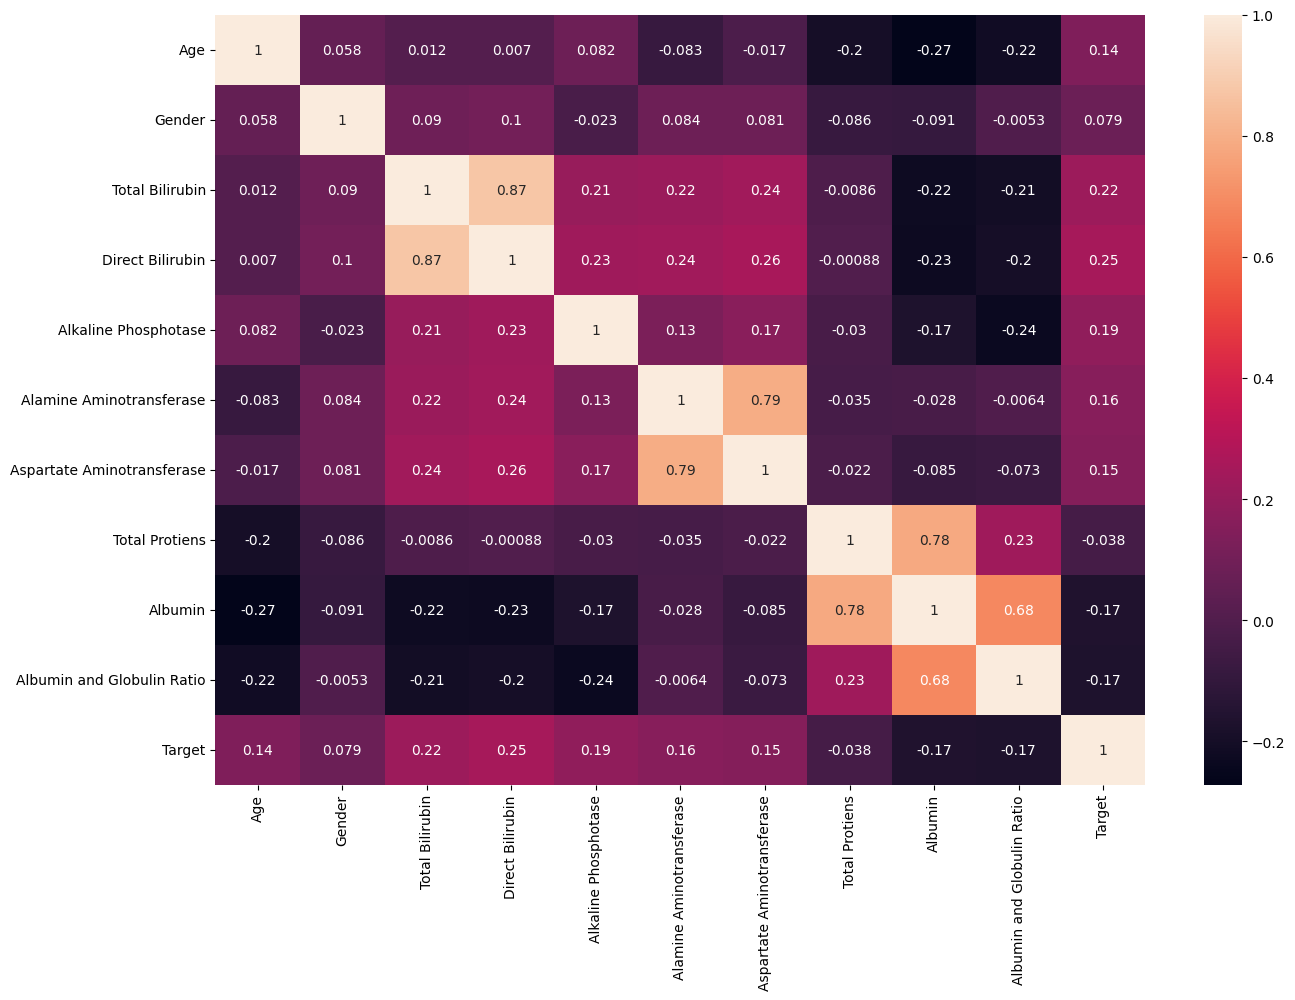

In [27]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

* Total Bilirubin, Direct Bilirubin --> This two Feature are Highly Correlate
* Alamine Aminotransferase,Aspartate Aminotransferase, --> This two Feature are Highly Correlate
* Total Protiens, Albumin -->This two Feature are Highly Correlate
* Albumin,Albumin and Globulin Ratio -->This two Feature are Highly Correlate
* so , i drop the feature one of them

# Outliers
* our dataset contains many outliers that represent valuable clinical information, we will not remove them. Instead, we will apply the Capping Method (Winsorization) — replacing extreme values beyond the lower and upper fences with the respective boundary limits — to retain important data while reducing the impact of extreme values.

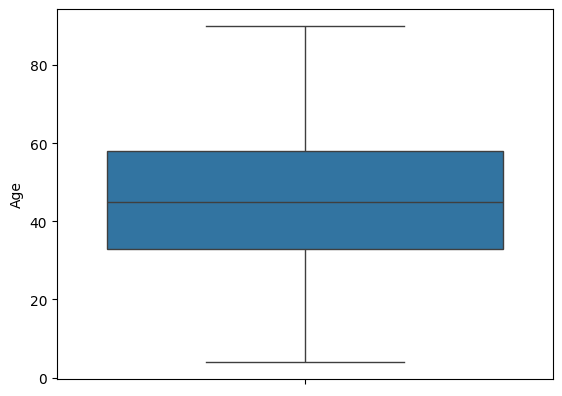

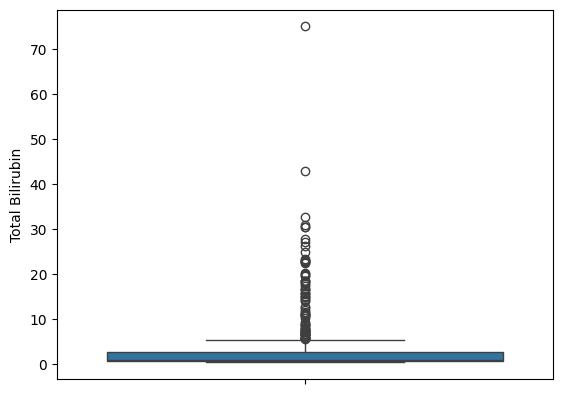

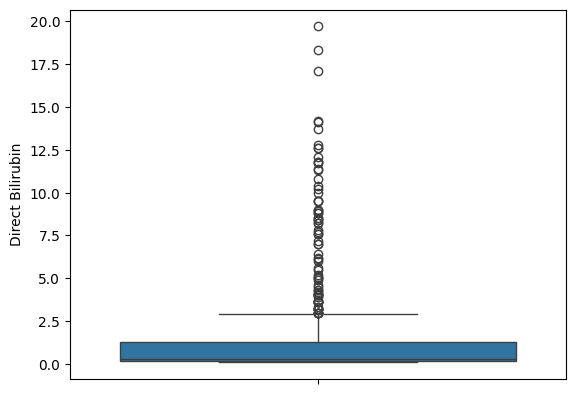

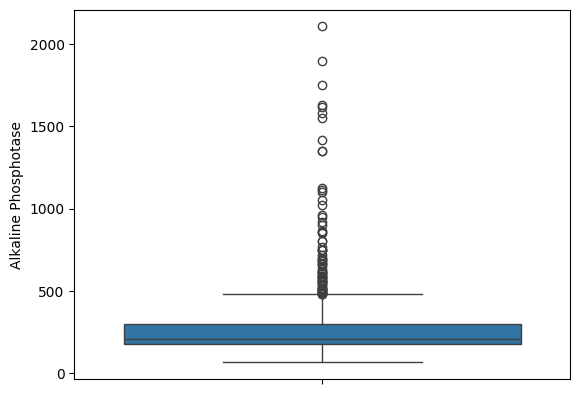

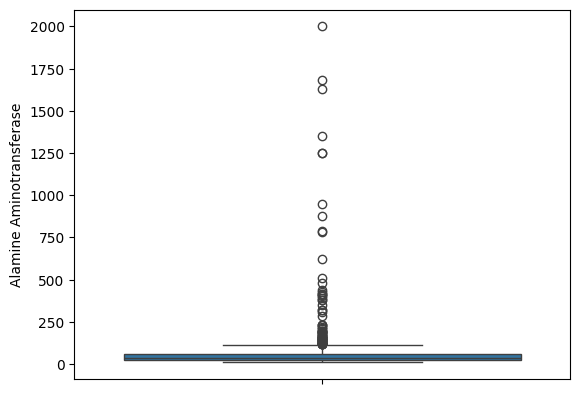

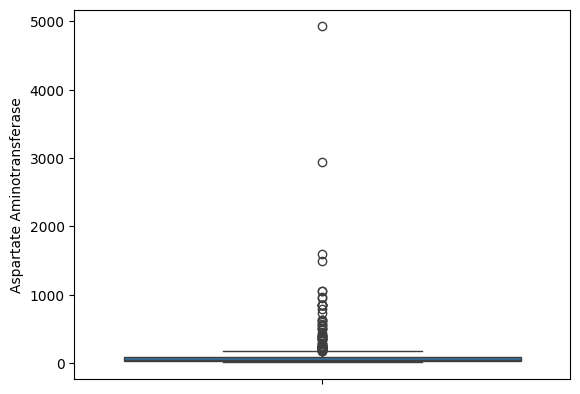

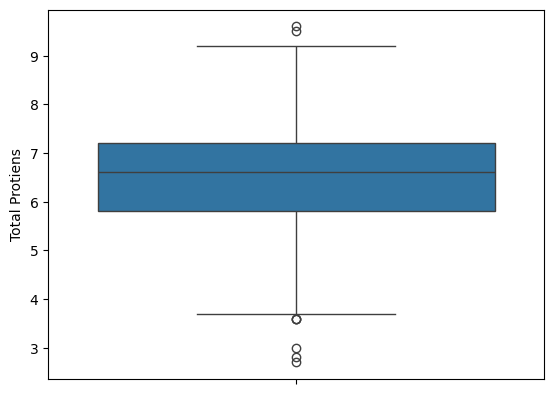

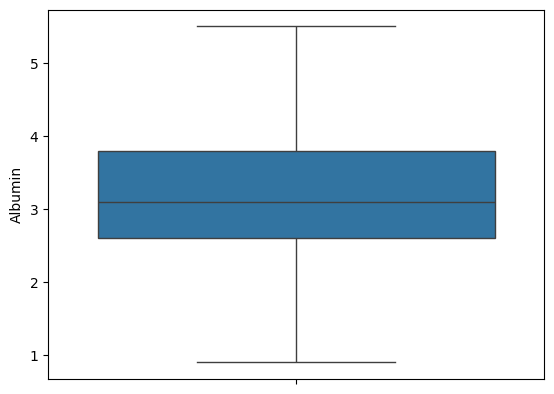

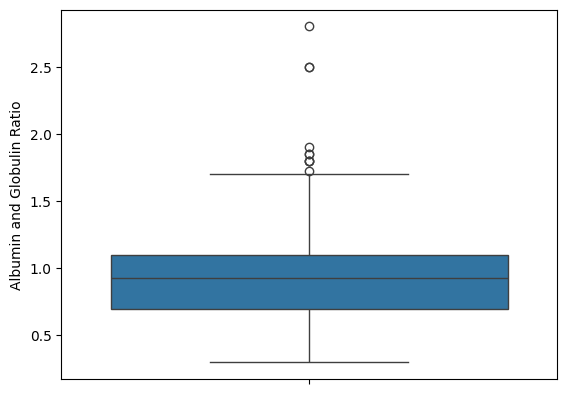

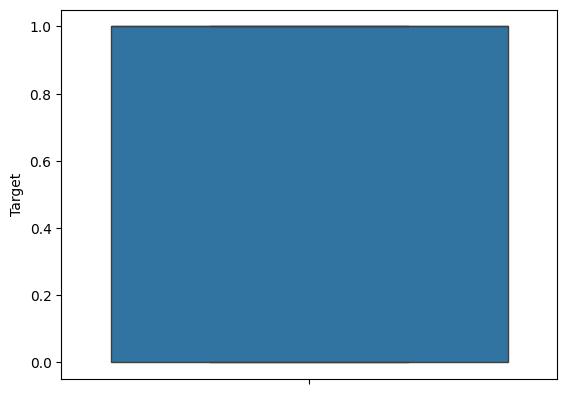

In [28]:
for i in num_hist:
  sns.boxplot(df[i])
  plt.show()

 ## Capping (Winsorization) Method

In [29]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower, lower,
                   np.where(df[col] > upper, upper, df[col]))
    return df

In [30]:
num_cols = ['Age', 'Total Bilirubin', 'Direct Bilirubin',
       'Alkaline Phosphotase', 'Alamine Aminotransferase',
       'Aspartate Aminotransferase', 'Total Protiens', 'Albumin',
       'Albumin and Globulin Ratio']
df_capped = cap_outliers_iqr(df.copy(), num_cols)
df_capped.shape

(570, 11)

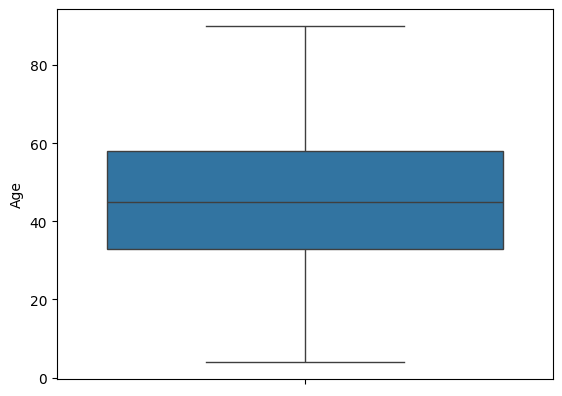

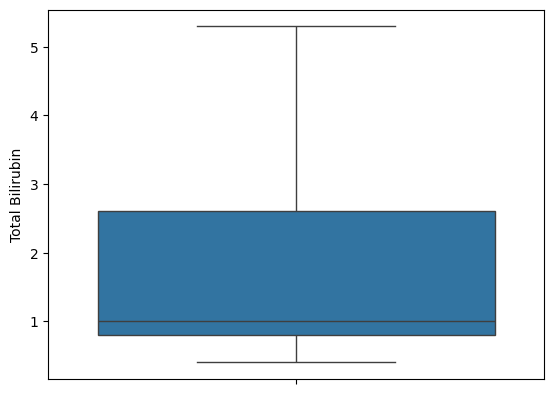

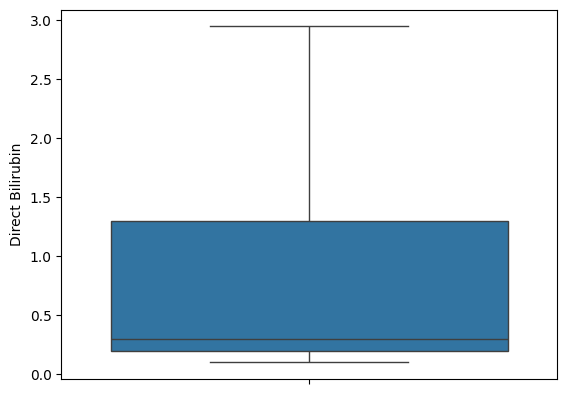

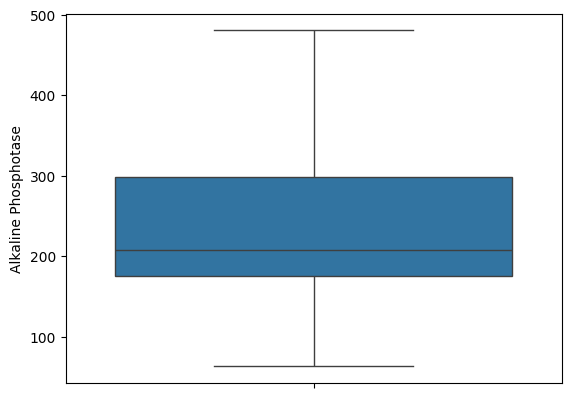

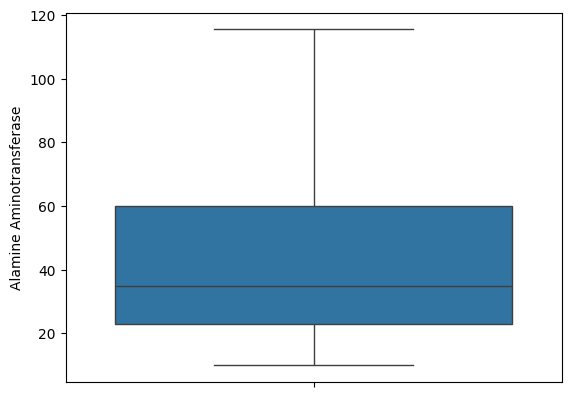

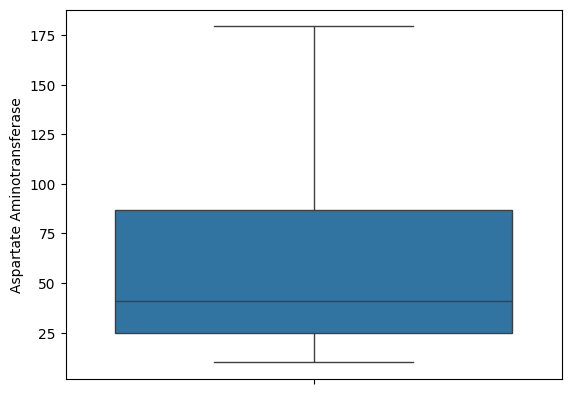

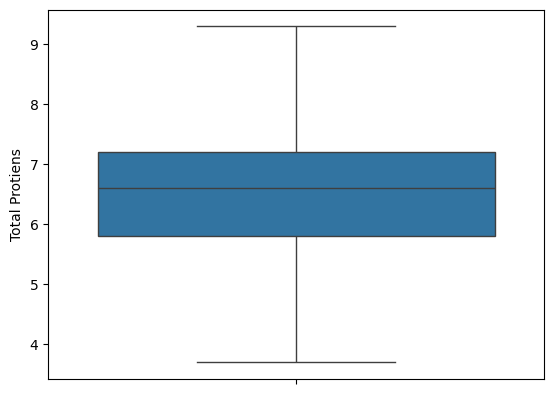

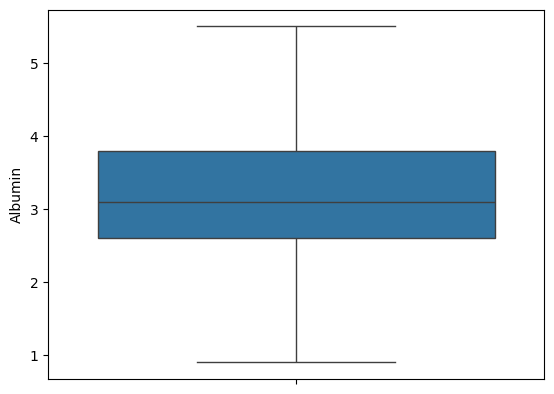

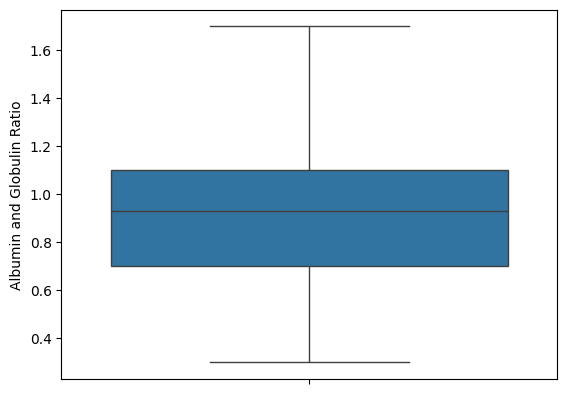

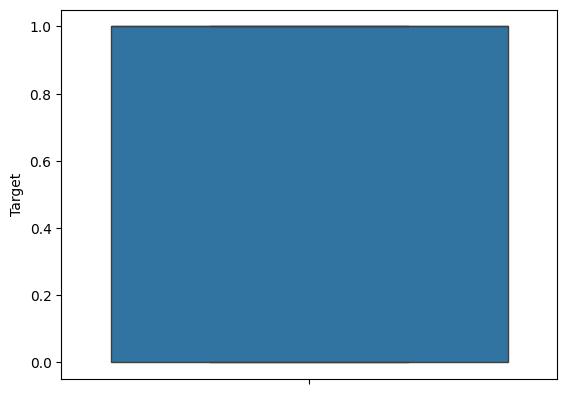

In [31]:
for i in num_hist:
  sns.boxplot(df_capped[i])
  plt.show()

# Split Data Train and Test

In [32]:
X = df_capped.drop(["Target",'Direct Bilirubin','Aspartate Aminotransferase','Albumin'], axis=1)
y = df_capped["Target"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling

In [34]:
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#Balancing the Data

The Target Variable have Imbalanced data so we used the SMOTE Method

In [35]:
from imblearn.over_sampling import SMOTE,ADASYN
from imblearn.combine import SMOTETomek

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Model Create

In [87]:
from numpy.random import uniform
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "SVM": SVC(random_state=42,kernel='linear'),
    "KNN": KNeighborsClassifier(weights='distance',algorithm='ball_tree'),
    "Naive Bayes": GaussianNB(),
}

In [88]:
results =[]
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"{name} F1-Score: {f1_score(y_test, y_pred)}")
    print(f"{name} Classification Report:\n{classification_report(y_test, y_pred)}\n")
    results.append([name,accuracy_score(y_test, y_pred),f1_score(y_test, y_pred)])
    print("-" * 50)

Decision Tree Accuracy: 0.6578947368421053
Decision Tree F1-Score: 0.7547169811320755
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.52      0.43        29
           1       0.81      0.71      0.75        85

    accuracy                           0.66       114
   macro avg       0.59      0.61      0.59       114
weighted avg       0.70      0.66      0.67       114


--------------------------------------------------
Random Forest Accuracy: 0.7105263157894737
Random Forest F1-Score: 0.7975460122699386
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.55      0.49        29
           1       0.83      0.76      0.80        85

    accuracy                           0.71       114
   macro avg       0.64      0.66      0.64       114
weighted avg       0.73      0.71      0.72       114


-----------------------------------------------

In [89]:
results_df = pd.DataFrame(results, columns=['Name',"Accuracy", "F1-Score"])
results_df

,Name,Accuracy,F1-Score
0,Decision Tree,0.657895,0.754717
1,Random Forest,0.710526,0.797546
2,Gradient Boosting,0.684211,0.777778
3,AdaBoost,0.719298,0.789474
4,XGBoost,0.684211,0.783133
5,LightGBM,0.710526,0.800000
6,Logistic Regression,0.614035,0.685714
7,SVM,0.561404,0.626866
8,KNN,0.614035,0.710526
9,Naive Bayes,0.570175,0.637037


# Comparison of all models

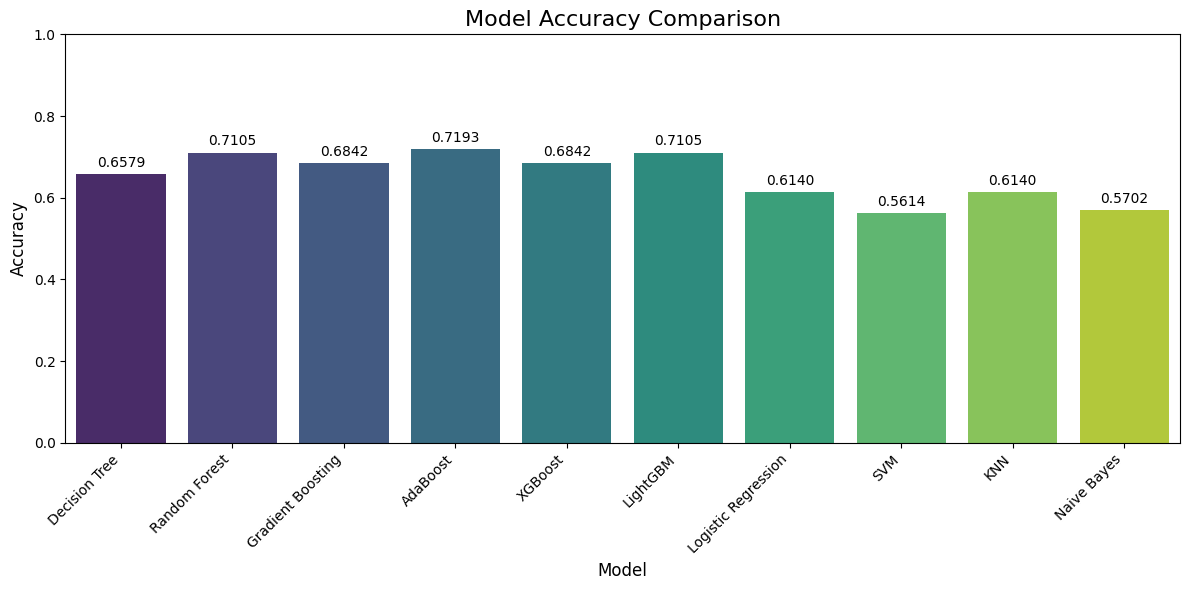

In [90]:
models_names = results_df['Name']
accuracy_scores = results_df['Accuracy']

plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x=models_names, y=accuracy_scores, palette='viridis')
plt.title("Model Accuracy Comparison", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

for index ,values in enumerate(accuracy_scores):
  bar_plot.text(index, values + 0.01, f'{values:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Most of Tree based models getting high accuracy .so, tree based models tune them**


#Hyperparameter Tunning

# Random Forest

In [54]:
scoring = {
    'f1': 'f1'
}

In [55]:


n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

random_search = {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf, 'bootstrap': bootstrap,
                 'random_state': [int(x) for x in range(0,43)]}



In [56]:
rf = RandomForestClassifier()
grid_search = RandomizedSearchCV(rf, random_search, cv=5, scoring='accuracy',random_state=23)
grid_search.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000],
                                        'random_state': [0, 1, 2, 3, 4, 5, 6, 7,
                                                         8, 9, 10, 11, 12, 13,
                                                         14, 15, 16, 17, 18, 19,
                                                         20, 21, 22, 23, 24, 25,
                                                         26, 27, 28, 29, ...]},
                   random_state=23, scoring='accuracy')

In [57]:
grid_search.best_params_

{'random_state': 28,
 'n_estimators': 1000,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': 90,
 'bootstrap': False}

In [58]:

best_model = RandomForestClassifier(bootstrap=False,max_depth=90,min_samples_leaf=2,min_samples_split=2,max_features='sqrt',n_estimators=1000,random_state=28)
best_model.fit(X_train_smote, y_train_smote)
y_pred_rf = best_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(f"Random Forest F1-Score: {f1_score(y_test, y_pred_rf)}")
print(f"Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf)}")


Random Forest Accuracy: 0.7631578947368421
Random Forest F1-Score: 0.8402366863905325
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.55      0.54        29
           1       0.85      0.84      0.84        85

    accuracy                           0.76       114
   macro avg       0.69      0.69      0.69       114
weighted avg       0.77      0.76      0.76       114



# Adaboosting

In [59]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',

}

In [60]:
base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)
adaboost = AdaBoostClassifier(estimator=base_estimator, random_state=42)

In [61]:
param_grid_ada = {
    'n_estimators':[int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'estimator__max_depth': [1, 2,3]
}


In [62]:
random_search_ada = RandomizedSearchCV(adaboost,param_distributions=param_grid_ada,n_iter=10,scoring='accuracy',verbose=2,n_jobs=-1,cv=5,random_state=42)
random_search_ada.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                                 random_state=42),
                                                random_state=42),
                   n_jobs=-1,
                   param_distributions={'estimator__max_depth': [1, 2, 3],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000]},
                   random_state=42, scoring='accuracy', verbose=2)

In [63]:
random_search_ada.best_params_

{'n_estimators': 1600, 'learning_rate': 0.2, 'estimator__max_depth': 3}

In [64]:
best_estimator_ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3, random_state=42), n_estimators=1600, learning_rate=0.2, random_state=42)
best_estimator_ada.fit(X_train_smote, y_train_smote)
y_pred_ada = best_estimator_ada.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada)}")
print(f"AdaBoost F1-Score: {f1_score(y_test, y_pred_ada)}")
print(f"AdaBoost Classification Report:\n{classification_report(y_test, y_pred_ada)}")

AdaBoost Accuracy: 0.6929824561403509
AdaBoost F1-Score: 0.7904191616766467
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.45      0.43        29
           1       0.80      0.78      0.79        85

    accuracy                           0.69       114
   macro avg       0.61      0.61      0.61       114
weighted avg       0.70      0.69      0.70       114



# LightGBM

In [65]:
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [66]:
param_grid_light = {
    'n_estimators': [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'num_leaves': [int(x) for x in np.linspace(start=20, stop=200, num=10)],
    'max_depth': [5, 7, -1],
    'learning_rate':  [0.01, 0.1, 0.2, 0.3],
    'scale_pos_weight': [1, np.sum(y_train == 0) / np.sum(y_train == 1)],
    'subsample': [0.7, 0.9],
    'feature_fraction': [0.7, 0.9],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
}


In [67]:
lgb_clf = lgb.LGBMClassifier(objective='binary', random_state=42)
grid_search_light = RandomizedSearchCV(
    estimator=lgb_clf, param_distributions=param_grid_light,
    scoring=scoring,
    refit='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search_light.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Number of positive: 321, number of negative: 321
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000060 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 759
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

RandomizedSearchCV(cv=5,
                   estimator=LGBMClassifier(objective='binary',
                                            random_state=42),
                   n_jobs=-1,
                   param_distributions={'feature_fraction': [0.7, 0.9],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [5, 7, -1],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000],
                                        'num_leaves': [20, 40, 60, 80, 100, 120,
                                                       140, 160, 180, 200],
                                        'reg_alpha': [0, 0.1, 0.5],
                                        'reg_lambda': [0, 0.1, 0.5],
                                        'scale_pos_weight': [1,
                                                             np.float64(0.4205607476635514)],
                                        'subsample': [0.7, 0.9]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'roc_auc': 'roc_auc'},
                   verbose=1)

In [68]:
grid_search_light.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1,
 'reg_lambda': 0.1,
 'reg_alpha': 0.5,
 'num_leaves': 100,
 'n_estimators': 800,
 'max_depth': 7,
 'learning_rate': 0.1,
 'feature_fraction': 0.9}

In [69]:
best_estimator_light = lgb.LGBMClassifier(subsample=0.7,scale_pos_weight =0.4205607476635514,reg_lambda=0.5,reg_alpha=0,num_leaves=140,n_estimators=800,max_depth=-1,learning_rate=0.3,feature_fraction=0.9,random_state=42)
best_estimator_light.fit(X_train_smote, y_train_smote)
y_pred_light = best_estimator_light.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_light)}")
print(f"AdaBoost F1-Score: {f1_score(y_test, y_pred_light)}")
print(f"AdaBoost Classification Report:\n{classification_report(y_test, y_pred_light)}")

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Info] Number of positive: 321, number of negative: 321
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 759
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

# Gradient Boosting

In [70]:
params_gb = {
    'n_estimators': [int(x) for x in np.linspace(start=200, stop=2000, num=10)],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample' : [0.5,0.7,0.9],
    'criterion': ['friedman_mse', 'squared_error'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2,4],
    'max_depth' : [int(x) for x in np.linspace(10, 110, num=11)],
    'random_state': [int(x) for x in range(0,43)],
    'max_features': ['auto', 'sqrt']
}

In [71]:
gb = GradientBoostingClassifier()
grid_search_gb = RandomizedSearchCV(
    estimator=gb, param_distributions=params_gb,
    scoring=scoring,
    refit='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search_gb.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
                   param_distributions={'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100, 110],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 400, 600, 800,
                                                         1000, 1200, 1400, 1600,
                                                         1800, 2000],
                                        'random_state': [0, 1, 2, 3, 4, 5, 6, 7,
                                                         8, 9, 10, 11, 12, 13,
                                                         14, 15, 16, 17, 18, 19,
                                                         20, 21, 22, 23, 24, 25,
                                                         26, 27, 28, 29, ...],
                                        'subsample': [0.5, 0.7, 0.9]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'roc_auc': 'roc_auc'},
                   verbose=1)

In [72]:
grid_search_gb.best_params_

{'subsample': 0.9,
 'random_state': 13,
 'n_estimators': 1200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 50,
 'learning_rate': 0.2,
 'criterion': 'friedman_mse'}

In [73]:
best_estimator_gb = GradientBoostingClassifier(subsample=0.9,random_state=42,n_estimators=800,min_samples_split=5,min_samples_leaf=1,max_features='sqrt',max_depth=90,learning_rate=0.1,criterion='friedman_mse')
best_estimator_gb.fit(X_train_smote, y_train_smote)
y_pred_gb = best_estimator_gb.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_gb)}")
print(f"AdaBoost F1-Score: {f1_score(y_test, y_pred_gb)}")
print(f"AdaBoost Classification Report:\n{classification_report(y_test, y_pred_gb)}")

AdaBoost Accuracy: 0.7456140350877193
AdaBoost F1-Score: 0.8284023668639053
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.52      0.51        29
           1       0.83      0.82      0.83        85

    accuracy                           0.75       114
   macro avg       0.67      0.67      0.67       114
weighted avg       0.75      0.75      0.75       114



# Decision Tree

In [74]:
params = {"criterion":("gini","entropy"),
          "splitter":("best", "random"),
          "max_depth":(list(range(1,20))),
          "min_samples_split":[2,3,4],
          "min_samples_leaf":list(range(1,20)),
          'random_state': [int(x) for x in range(0,43)]
          }

In [75]:
dt_gr = DecisionTreeClassifier()
dt_grid = GridSearchCV(dt_gr,params,scoring="accuracy",n_jobs= -1,verbose=2,cv=2)

In [76]:
dt_grid.fit(X_train_smote,y_train_smote)
best_params = dt_grid.best_params_
print(f"Best paramters: {best_params})")

Fitting 2 folds for each of 186276 candidates, totalling 372552 fits
Best paramters: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'random_state': 41, 'splitter': 'random'})


In [77]:
best_dt = DecisionTreeClassifier(criterion='entropy',max_depth=12,min_samples_leaf=1,min_samples_split=2,splitter='random',random_state=41)
best_dt.fit(X_train_smote, y_train_smote)
y_pred_dt = best_dt.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_dt)}")
print(f"AdaBoost F1-Score: {f1_score(y_test, y_pred_dt)}")
print(f"AdaBoost Classification Report:\n{classification_report(y_test, y_pred_dt)}")

AdaBoost Accuracy: 0.7105263157894737
AdaBoost F1-Score: 0.7975460122699386
AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.55      0.49        29
           1       0.83      0.76      0.80        85

    accuracy                           0.71       114
   macro avg       0.64      0.66      0.64       114
weighted avg       0.73      0.71      0.72       114



# Xgboost

In [79]:
xgb_model = XGBClassifier()

In [80]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 1, 5]
}

In [81]:
grid_search_xgb = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist, n_iter=10,
                                   scoring='accuracy', cv=5, n_jobs=-1, random_state=42)

In [82]:
grid_search_xgb.fit(X_train_smote, y_train_smote)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 1, 5],
                                        'learning_rate': [0.01, 0.1, 0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy')

In [83]:
grid_search_xgb.best_params_

{'subsample': 0.9,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.2,
 'gamma': 0,
 'colsample_bytree': 1.0}

In [84]:
best_estimator_xgb = XGBClassifier(subsample=0.9,n_estimators=300,min_child_weight=1,max_depth=6,learning_rate=0.2,gamma=0,colsample_bytree=1.0)
best_estimator_xgb.fit(X_train_smote, y_train_smote)
y_pred_xgb = best_estimator_xgb.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb)}")
print(f"XGBoost F1-Score: {f1_score(y_test, y_pred_xgb)}")
print(f"XGBoost Classification Report:\n{classification_report(y_test, y_pred_xgb)}")

XGBoost Accuracy: 0.7017543859649122
XGBoost F1-Score: 0.7976190476190477
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.45      0.43        29
           1       0.81      0.79      0.80        85

    accuracy                           0.70       114
   macro avg       0.61      0.62      0.62       114
weighted avg       0.71      0.70      0.70       114



# Model Comparison After Tune

In [85]:
models = ["Random Forest", "AdaBoost", "LightGBM", "XGBoost","Gradient Boosting" , "Decision Tree"]
accuracy = [
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_ada),
    accuracy_score(y_test, y_pred_light),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_dt)
]


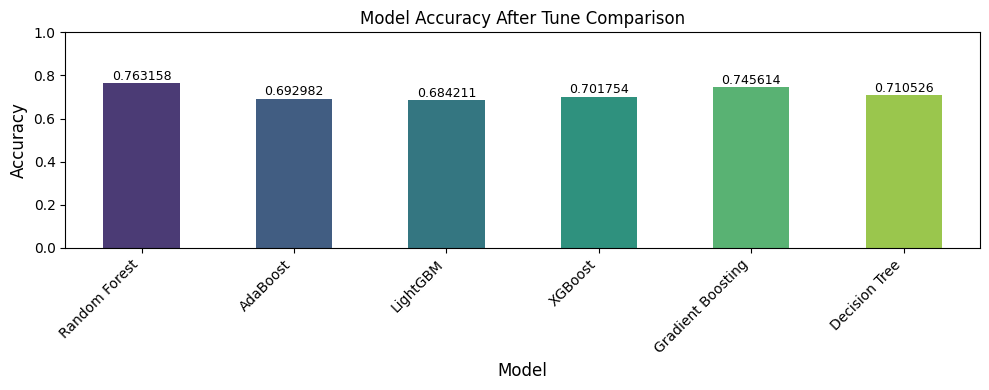

In [86]:
plt.figure(figsize=(10, 4))
bar_plot = sns.barplot(y=accuracy,x=models,width=0.5, palette='viridis')
plt.title("Model Accuracy After Tune Comparison")
plt.ylabel("Accuracy",fontsize=12)
plt.xlabel("Model",fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
for index ,values in enumerate(accuracy):
  bar_plot.text(index, values+0.001 ,f'{values:4f}',ha = 'center' ,va ='bottom',fontsize=9)

plt.tight_layout()
plt.show()


# Model Comparison Report

* Using **Random Forest**, we achieved the **highest accuracy score of 76.31%**, demonstrating strong predictive ability for identifying liver disease.  
* **Gradient Boosting (74.56%)** and **XGBoost (70.17%)** also performed well, showing that ensemble-based methods are more effective for this dataset.  

* Before tuning, **AdaBoost (71.93%)**, **LightGBM (71.05%)**, and **Random Forest (71.05%)** achieved good results, while **Logistic Regression (61.40%)**, **SVM (61.40%)**, and **Naive Bayes (57.02%)** had lower accuracies.  
* After tuning, model performance improved overall, and **Random Forest** was finalized as the **best model** because of its balance between accuracy, interpretability, and robustness.  



#  Report on Challenges Faced

### **1. Missing and Duplicate Values**
**Problem:**  
Presence of null values and duplicate rows affecting data quality.  
**Solution:**  
Filled null values with the **median** and removed duplicates.  
**Why:**  
Median maintains data distribution and prevents skew; removing duplicates ensures model learns unique patterns.

---

### **2. Target Label Conversion**
**Problem:**  
Target column contained values `1` and `2` which were inconsistent for binary classification.  
**Solution:**  
Converted them to **0 and 1** to represent healthy vs. liver disease patients.  
**Why:**  
Binary labels are required for most classification algorithms.

---

### **3. Imbalanced Dataset**
**Problem:**  
Target variable was imbalanced — more liver disease cases (`1`) than healthy ones (`0`).  
**Solution:**  
Used **class balancing** and focused on recall and precision during evaluation.  
**Why:**  
To prevent bias toward the majority class and improve prediction of minority cases.

---

### **4. High Correlation Between Features**
**Problem:**  
Some features had **strong positive correlation** with each other.  
**Solution:**  
Dropped one feature from each highly correlated pair.  
**Why:**  
Reduces multicollinearity, improves interpretability, and increases model stability.

---

### **5. Outliers**
**Problem:**  
Dataset contained **valuable outliers** representing important clinical information.  
**Solution:**  
Applied **Capping Method (Winsorization)** — replaced extreme values with boundary limits.  
**Why:**  
Preserves critical information while reducing the influence of extreme values.


---

### **6. Small Dataset Size**
**Problem:**  
The dataset used was **very small**, consisting of only **583 observations**, and a few extreme outliers had to be capped.  
**Solution:**  
Implemented **robust preprocessing**, careful model tuning, and cross-validation to make the most of available data.  
**Why:**  
Small datasets can lead to overfitting and limit generalization. Even though high accuracy was achieved, model performance on larger, real-world datasets may decrease due to variability and noise.





##  Suggestions for Liver Patients

### *1. Regular Health Monitoring*  
- Take **Liver Function Tests (LFTs)** regularly.  
- Monitor **Bilirubin**, **AST**, **ALT**, and **Albumin** levels.  
- Early detection helps prevent severe liver damage.

### *2. Maintain a Healthy Lifestyle*  
- Avoid **alcohol** and **smoking**.  
- Follow a **balanced diet** rich in vegetables and fiber.  
- Maintain **healthy body weight** to prevent fatty liver.

### *3. Medical Consultation*  
- Consult a **doctor or hepatologist** if symptoms like fatigue, yellow eyes, or abdominal pain appear.  
- Follow prescribed medications properly and avoid self-medication.

### *4. Preventive Measures*  
- Get **vaccinated for Hepatitis A & B**.  
- Drink clean water and avoid contaminated food.  
- Manage **diabetes, cholesterol**, and other conditions affecting liver health.



# Project Summary

The dataset contained **missing values**, **duplicates**, **imbalanced classes**, and **outliers**, all of which were addressed in preprocessing.  
* **Null values** were filled with median; **duplicates** were dropped; **target labels** converted to 0 and 1.  
* **Outliers** handled using **Winsorization (Capping Method)** to preserve important data.  
* Highly **correlated features** were reduced for better model performance.  
* Models used: **Decision Tree, Random Forest, Gradient Boosting, AdaBoost, XGBoost, LightGBM, Logistic Regression, SVM, KNN, Naive Bayes.**  
* After tuning, **Random Forest** achieved the **highest accuracy (76.31%)**, making it the most reliable model for predicting liver disease.  
* The dataset used was **very small (583 samples)** and **highly imbalanced**, which may affect generalization on larger datasets.  
* Despite this, the workflow demonstrates strong data-handling techniques and shows how **ensemble models** can provide meaningful predictions even with limited medical data.  
* The project demonstrates the power of **data preprocessing, feature engineering, and ensemble models** in healthcare prediction systems.


# ⚠️ Problems

* The dataset was **very small**, containing only **583 observations**, and a few outliers were **removed or capped** to retain valuable information.

* It was **highly imbalanced**, with positive cases nearly **three times the number of negative ones**, affecting model generalization.

* Although the model achieved a perfect score, its performance on larger and more diverse datasets is expected to decline due to overfitting and limited data diversity.